# Introduction to Analytical Tables

The cron process makes a number of tables available for analysis. These tables are updated at the beginning of each day. 

| Table      | Description      |
| ------------- | ------------- |
| sensor_readings | The most "raw" data from the Coris API. One row per Sensor and UTC timestamp. Devices have 2 Sensors, one for Temperature and one for Humidity so each Device will typically have two rows per UTC timestamp. |
| device_readings | Sensor readings reorganized to one row per Device and UTC timestamp, with Sensor measurements across columns instead of rows. |
| sensors | Information about the unique sensors. One row per SensorID_Coris. Includes information extracted from SensorName. Join this to sensor_readings during analysis to enhance with Building, Room, Direction, etc. |
| devices | Information about unique devices. One row per DeviceID_Coris. Includes information extracted from SensorName. Join this to device_readings during analysis to enhance with Building, Room, Direction, etc. |
| utcs | Information related to the UTC times in various datasets. Join to sensor_readings or device_readings to enhance with Date, Time, Year, Hour, Weekday, etc. |
| sensor_readings_daily | Example of sensor readings summarized to the daily level which reduces row count by 99.3% for even faster queries. You can create different cubes to support common analysis patterns. |
| device_readings_daily | Example of device readings summarized to the daily level. |

Let's take a look at each of the tables. 

In [1]:
import duckdb
duckdb.sql("SELECT * FROM read_parquet('../data/sensor_readings.parquet') LIMIT 5").df()

,SensorReadingUTC,Source,DeviceID,DeviceName,SensorID,SensorName,SensorType,SensorReadingF,SensorReadingRh,QueryUTC,SensorReadingUTC_SecondsFromPrior
0,1700152287,Coris,coris:12162,Peabody TH-L Mammal Hall D444,coris:21373,PYPM__0100104SET____ Temp YPM 104_D444,Temperature,70.790001,NaN,<NA>,<NA>
1,1700152887,Coris,coris:12162,Peabody TH-L Mammal Hall D444,coris:21373,PYPM__0100104SET____ Temp YPM 104_D444,Temperature,70.809998,NaN,<NA>,600
2,1700153487,Coris,coris:12162,Peabody TH-L Mammal Hall D444,coris:21373,PYPM__0100104SET____ Temp YPM 104_D444,Temperature,70.790001,NaN,<NA>,600
3,1700154087,Coris,coris:12162,Peabody TH-L Mammal Hall D444,coris:21373,PYPM__0100104SET____ Temp YPM 104_D444,Temperature,70.809998,NaN,<NA>,600
4,1700154687,Coris,coris:12162,Peabody TH-L Mammal Hall D444,coris:21373,PYPM__0100104SET____ Temp YPM 104_D444,Temperature,70.790001,NaN,<NA>,600


In [2]:
duckdb.sql("SELECT * FROM read_parquet('../data/device_readings.parquet') LIMIT 5").df()

,Source,DeviceID,DeviceName,Sensors,SensorNames,SensorTypes,SensorReadingUTC,QueryUTC,SensorReadingF,SensorReadingRh
0,Coris,coris:12162,Peabody TH-L Mammal Hall D444,"coris:21374, coris:21373","PYPM__0100104SET____ RH YPM 104_D444 , PYPM__0...","Humidity, Temperature",1700152287,<NA>,70.790001,NaN
1,Coris,coris:12162,Peabody TH-L Mammal Hall D444,"coris:21374, coris:21373","PYPM__0100104SET____ RH YPM 104_D444 , PYPM__0...","Humidity, Temperature",1700152887,<NA>,70.809998,NaN
2,Coris,coris:12162,Peabody TH-L Mammal Hall D444,"coris:21374, coris:21373","PYPM__0100104SET____ RH YPM 104_D444 , PYPM__0...","Humidity, Temperature",1700153487,<NA>,70.790001,NaN
3,Coris,coris:12162,Peabody TH-L Mammal Hall D444,"coris:21374, coris:21373","PYPM__0100104SET____ RH YPM 104_D444 , PYPM__0...","Humidity, Temperature",1700154087,<NA>,70.809998,NaN
4,Coris,coris:12162,Peabody TH-L Mammal Hall D444,"coris:21374, coris:21373","PYPM__0100104SET____ RH YPM 104_D444 , PYPM__0...","Humidity, Temperature",1700154687,<NA>,70.790001,NaN


In [3]:
duckdb.sql("SELECT * FROM read_parquet('../data/sensors.parquet') LIMIT 5").df()

,Source,SensorID,SensorName,SensorType,DeviceID,DeviceSerialFromName,BuildingID,Building,Room,CardinalDirection
0,LI-COR,licor:10740550-10740550-2,ICSC__010C149________RH,RH,licor:10740550,RH,FLOATER,Unknown,FLOATER,None
1,LI-COR,licor:10740550-10740550-1,ICSC__010C149________Temperature,Temperature,licor:10740550,Temperature,FLOATER,Unknown,FLOATER,None
2,Coris,coris:21378,RH KGL 21_D0B2,Humidity,coris:12167,D0B2,KGL,Kline Geology Laboratory,21,Not Indicated
3,Coris,coris:21377,Temp KGL 21_D0B2,Temperature,coris:12167,D0B2,KGL,Kline Geology Laboratory,21,Not Indicated
4,LI-COR,licor:22202142-22179174-2,RX Station 1_RH,RH,licor:22202142,RH,Station,Unknown,1,Not Indicated


In [4]:
duckdb.sql("SELECT * FROM read_parquet('../data/devices.parquet') LIMIT 5").df()

,Source,DeviceID,DeviceName,Sensors,SensorNames,SensorTypes,DeviceSerialFromName,BuildingID,Building,Room,CardinalDirection
0,LI-COR,licor:10740550,ICSC__010C149_______,"licor:10740550-10740550-2, licor:10740550-1074...","ICSC__010C149________RH, ICSC__010C149________...","RH, Temperature",RH,FLOATER,Unknown,FLOATER,None
1,Coris,coris:12167,Peabody TH-L Upper Great Hall D0B2,"coris:21378, coris:21377","RH KGL 21_D0B2, Temp KGL 21_D0B2","Humidity, Temperature",D0B2,KGL,Kline Geology Laboratory,21,Not Indicated
2,LI-COR,licor:22202142,RX Station 1,"licor:22202142-22179174-2, licor:22202142-2217...","RX Station 1_RH, RX Station 1_RH, RX Station 1...","RH, RH, Temperature, Temperature",Temperature,Station,Unknown,1,Not Indicated
3,LI-COR,licor:22202141,RX Station 2,"licor:22202141-22179175-2, licor:22202141-2217...","RX Station 2_RH, RX Station 2_Temperature","RH, Temperature",RH,Station,Unknown,2,Not Indicated
4,Coris,coris:12162,Peabody TH-L Mammal Hall D444,"coris:21374, coris:21373","RH YPM 104_D444 , Temp YPM 104_D444","Humidity, Temperature",D444,YPM,Yale Peabody Museum,104,Not Indicated


In [5]:
duckdb.sql("SELECT * FROM read_parquet('../data/utcs.parquet') LIMIT 5").df()

,UTC,datetime_utc,datetime_est,date,time,year,month,day_of_week,day_of_week_monday1_sunday7,hour_24,hour_12,am_pm
0,1753743360,2025-07-28 16:56:00,2025-07-28 10:56:00-06:00,2025-07-28,12:56:00,2025,7,Monday,1,12,0,PM
1,1753481220,2025-07-25 16:07:00,2025-07-25 10:07:00-06:00,2025-07-25,12:07:00,2025,7,Friday,5,12,0,PM
2,1715732487,2024-05-14 18:21:27,2024-05-14 12:21:27-06:00,2024-05-14,14:21:27,2024,5,Tuesday,2,14,2,PM
3,1735393287,2024-12-28 06:41:27,2024-12-27 23:41:27-07:00,2024-12-28,01:41:27,2024,12,Saturday,6,1,1,AM
4,1753219080,2025-07-22 15:18:00,2025-07-22 09:18:00-06:00,2025-07-22,11:18:00,2025,7,Tuesday,2,11,11,AM


In [6]:
duckdb.sql("SELECT * FROM read_parquet('../data/sensor_readings_daily.parquet') LIMIT 5").df()

,Source,date,SensorID,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
0,Coris,2023-11-16,coris:21373,117,8230.749023,0.000000,69.800003,NaN,70.919998,NaN
1,Coris,2023-11-16,coris:21374,117,0.000000,5728.020508,NaN,47.709999,NaN,49.770000
2,Coris,2023-11-16,coris:21375,117,7981.562988,0.000000,68.070000,NaN,68.360001,NaN
3,Coris,2023-11-16,coris:21376,117,0.000000,5749.491211,NaN,47.919998,NaN,51.080002
4,Coris,2023-11-16,coris:21377,117,8523.317383,0.000000,72.250000,NaN,73.580002,NaN


In [7]:
duckdb.sql("SELECT * FROM read_parquet('../data/device_readings_daily.parquet') LIMIT 5").df()

,Source,date,DeviceID,row_count,SensorReadingF_sum,SensorReadingRh_sum,SensorReadingF_min,SensorReadingRh_min,SensorReadingF_max,SensorReadingRh_max
0,Coris,2023-11-16,coris:12162,234,8230.749023,5728.020508,69.800003,47.709999,70.919998,49.770000
1,Coris,2023-11-16,coris:12167,234,8523.317383,4505.799805,72.250000,36.630001,73.580002,39.950001
2,Coris,2023-11-16,coris:12169,234,7981.562988,5749.491211,68.070000,47.919998,68.360001,51.080002
3,Coris,2023-11-17,coris:12162,288,10010.748047,7754.789551,68.769997,47.919998,70.449997,57.389999
4,Coris,2023-11-17,coris:12167,288,10465.308594,6665.239746,71.559998,37.580002,73.400002,51.360001


# Sample Queries

<Axes: xlabel='Weekday', ylabel='Mean SensorReadingF'>

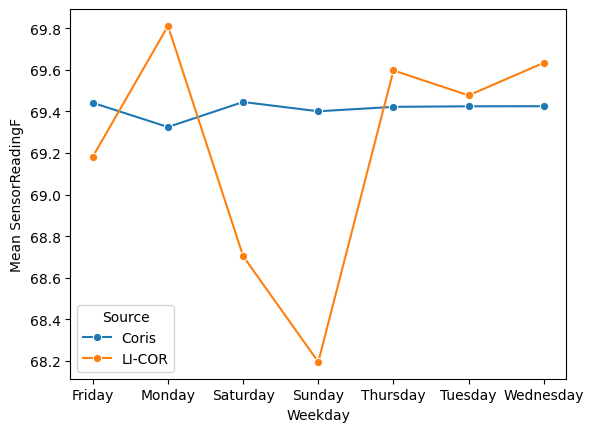

In [8]:
# Example: Average reading by Weekday. 

# join utcs to get weekday. 
# df converts results to a pandas DataFrame.

# use abs(dr.SensorReadingUTC - dr.QueryUTC) < 60 * 5 to remove old sensor readings.

import seaborn as sns

data = duckdb.sql("""
    SELECT day_of_week as Weekday, Source, avg(SensorReadingF) as 'Mean SensorReadingF'
    FROM read_parquet('../data/device_readings.parquet') AS dr
    INNER JOIN read_parquet('../data/utcs.parquet') AS u ON 
        dr.SensorReadingUTC = u.UTC
    GROUP BY day_of_week, Source
    ORDER BY day_of_week, Source
""").df()

sns.lineplot(x='Weekday', y='Mean SensorReadingF', hue='Source', data=data, marker='o')

<Axes: xlabel='Weekday', ylabel='Mean SensorReadingF'>

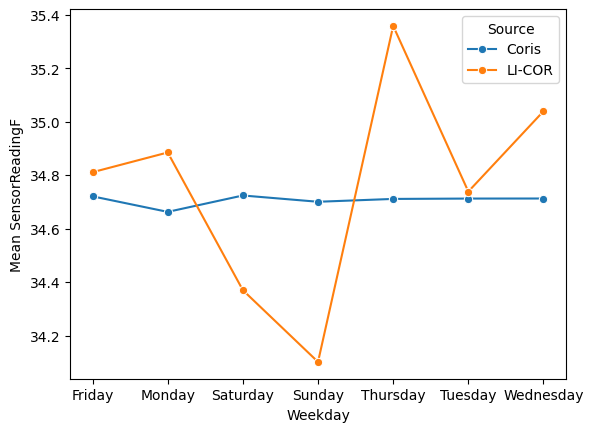

In [9]:
# Example: Average reading by Weekday - using the cubes.

# join utcs to get weekday. 
# df converts results to a pandas DataFrame.

# cubes already have old sensor readings removed. 

import seaborn as sns

data = duckdb.sql("""
    SELECT day_of_week as Weekday, Source, sum(SensorReadingF_sum) / sum(row_count) as 'Mean SensorReadingF'
    FROM read_parquet('../data/device_readings_daily.parquet') AS drd
    INNER JOIN (SELECT DISTINCT date, day_of_week FROM read_parquet('../data/utcs.parquet')) AS u
        ON drd.date = u.date
    GROUP BY day_of_week, Source
    ORDER BY day_of_week, Source
""").df()

# need DISTINCT on utcs to prevent duplication!

sns.lineplot(x='Weekday', y='Mean SensorReadingF', hue='Source', data=data, marker='o')

In [10]:
# Buildings: Number of Devices, First Reading.

# join utcs to get date. 
# join devices to get building info.
# df converts results to a pandas DataFrame.

duckdb.sql("""
    SELECT dr.Source, Building, min(date) as 'First Reading', count(DISTINCT dr.DeviceID) as 'Count of Devices'
    FROM read_parquet('../data/device_readings.parquet') AS dr
    INNER JOIN read_parquet('../data/utcs.parquet') AS u
        ON dr.SensorReadingUTC = u.UTC
    INNER JOIN read_parquet('../data/devices.parquet') AS d
        ON d.DeviceID = dr.DeviceID
    GROUP BY dr.Source, Building
    ORDER BY min(date)
""").df()

,Source,Building,First Reading,Count of Devices
0,Coris,Kline Geology Laboratory,2023-11-16,1
1,Coris,Yale Peabody Museum,2023-11-16,2
2,LI-COR,Unknown,2024-12-12,3


In [11]:
# Readings that differ from the Query UTC. These could be data errors if the difference is large.
duckdb.sql("""
    SELECT QueryUTC, SensorReadingUTC, (SensorReadingUTC - QueryUTC) / 60 as 'Difference (Minutes)'
    FROM read_parquet('../data/sensor_readings.parquet') 
    WHERE abs(SensorReadingUTC - QueryUTC) > 60 * 1
    ORDER BY abs(SensorReadingUTC - QueryUTC) DESC
""").df()

,QueryUTC,SensorReadingUTC,Difference (Minutes)
0,1763224329,1763224202,-2.116667
1,1763224329,1763224202,-2.116667
2,1763224329,1763224209,-2.000000
3,1763224329,1763224209,-2.000000
4,1763224329,1763224227,-1.700000
5,1763224329,1763224227,-1.700000
